# Global Cities Climate & Development Analysis (1990-2018)

This notebook analyzes climate and development data across **10 major cities** worldwide:

| City | Country | Region |
|------|---------|--------|
| Cape Town | South Africa | Africa |
| Hyderabad | India | Asia |
| Kingston | Jamaica | Caribbean |
| New York City | United States | North America |
| Rome | Italy | Europe |
| Marseille | France | Europe |
| Toronto | Canada | North America |
| Calgary | Canada | North America |
| London | United Kingdom | Europe |
| Oslo | Norway | Europe |

**Goals:**
- Compare climate patterns across different latitudes and geographies
- Analyze global warming trends across cities
- Compare development trajectories and emissions
- Identify patterns and outliers among cities

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.signal import find_peaks
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# Define city-specific color palette
CITY_COLORS = {
    'Cape Town': '#FF6B6B',      # Coral Red
    'Hyderabad': '#4ECDC4',       # Teal
    'Kingston': '#45B7D1',        # Sky Blue
    'New York City': '#96CEB4',    # Sage Green
    'Rome': '#FFEAA7',            # Cream Yellow
    'Marseille': '#DDA0DD',       # Plum
    'Toronto': '#98D8C8',          # Mint
    'Calgary': '#F7DC6F',         # Mustard
    'London': '#BB8FCE',          # Light Purple
    'Oslo': '#85C1E9'             # Light Blue
}

# Color scheme for variables
COLORS = {
    'temperature': '#E74C3C',     # Red
    'co2': '#3498DB',            # Blue
    'population': '#27AE60',      # Green
    'gdp': '#9B59B6',            # Purple
    'precipitation': '#1ABC9C',   # Teal
    'positive': '#2ECC71',       # Green
    'negative': '#E74C3C',       # Red
    'primary': '#2C3E50',        # Dark
    'secondary': '#7F8C8D'       # Gray
}

print("Libraries loaded successfully!")
print(f"Available cities: {list(CITY_COLORS.keys())}")

Libraries loaded successfully!
Available cities: ['Cape Town', 'Hyderabad', 'Kingston', 'New York City', 'Rome', 'Marseille', 'Toronto', 'Calgary', 'London', 'Oslo']


In [2]:
# Load dataset
df = pd.read_csv('Data/merged_all_locations_yearly_1990_2018_clean.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nCities: {df['city'].nunique()}")
print(f"Year range: {df['year'].min()} - {df['year'].max()}")

# Quick overview
df.head(10)

Dataset shape: (272, 16)

Columns: ['year', 'temp_mean_K', 'wind_speed_mean_ms', 'precip_total_mm', 'location_code', 'city', 'country', 'population', 'built_up_area_m2', 'gdp_ppp', 'hdi', 'pop_exposed_flood_10yr', 'co2_emissions_ton', 'ghg_emissions_ton', 'nox_emissions_ton', 'pm25_emissions_ton']

Cities: 10
Year range: 1990 - 2018


,year,temp_mean_K,wind_speed_mean_ms,precip_total_mm,location_code,city,country,population,built_up_area_m2,gdp_ppp,hdi,pop_exposed_flood_10yr,co2_emissions_ton,ghg_emissions_ton,nox_emissions_ton,pm25_emissions_ton
0,1990,289.539768,8.263012,594.433150,-33.9N_18.5E,Cape Town,South Africa,2.028241e+06,136652367.0,4.067584e+07,0.7110,206.090,7.212327e+06,9.070311e+06,25096.370368,12116.047542
1,1991,289.317261,7.360679,460.223021,-33.9N_18.5E,Cape Town,South Africa,2.073430e+06,138453452.2,4.104569e+07,0.7178,209.610,7.260609e+06,9.165988e+06,25366.976159,12160.387767
2,1992,289.372513,8.470232,650.794682,-33.9N_18.5E,Cape Town,South Africa,2.118618e+06,140254537.4,4.141554e+07,0.7246,213.130,7.308891e+06,9.261665e+06,25637.581949,12204.727991
3,1993,289.674092,7.512518,572.032984,-33.9N_18.5E,Cape Town,South Africa,2.163806e+06,142055622.6,4.178539e+07,0.7314,216.650,7.357174e+06,9.357342e+06,25908.187740,12249.068216
4,1994,289.775767,7.520717,432.921544,-33.9N_18.5E,Cape Town,South Africa,2.208994e+06,143856707.8,4.215524e+07,0.7382,220.170,7.405456e+06,9.453019e+06,26178.793531,12293.408441
5,1995,289.498728,7.917485,565.990716,-33.9N_18.5E,Cape Town,South Africa,2.254182e+06,145657793.0,4.252509e+07,0.7450,223.690,7.453738e+06,9.548696e+06,26449.399322,12337.748666
6,1996,289.277554,8.159300,737.764823,-33.9N_18.5E,Cape Town,South Africa,2.305886e+06,147756373.2,4.408384e+07,0.7370,227.892,7.502021e+06,9.644374e+06,26720.005112,12382.088891
7,1997,289.470655,7.877849,590.093166,-33.9N_18.5E,Cape Town,South Africa,2.357589e+06,149854953.4,4.564260e+07,0.7290,232.094,7.550303e+06,9.740051e+06,26990.610903,12426.429116
8,1998,289.595721,7.735895,474.591122,-33.9N_18.5E,Cape Town,South Africa,2.409293e+06,151953533.6,4.720135e+07,0.7210,236.296,7.598585e+06,9.835728e+06,27261.216694,12470.769341
9,1999,289.913094,7.813030,485.623967,-33.9N_18.5E,Cape Town,South Africa,2.460996e+06,154052113.8,4.876011e+07,0.7130,240.498,7.646868e+06,9.931405e+06,27531.822485,12515.109566


In [3]:
# Summary statistics by city
city_summary = df.groupby('city').agg({
    'temp_mean_K': ['mean', 'std', 'min', 'max'],
    'precip_total_mm': 'mean',
    'population': 'mean',
    'gdp_ppp': 'mean',
    'hdi': 'mean',
    'co2_emissions_ton': 'mean'
}).round(2)

city_summary.columns = ['Avg Temp (K)', 'Temp Std', 'Min Temp', 'Max Temp',
                       'Avg Precip', 'Avg Population', 'Avg GDP', 'Avg HDI', 'Avg CO2']

print("City Summary Statistics:")
city_summary

City Summary Statistics:


,Avg Temp (K),Temp Std,Min Temp,Max Temp,Avg Precip,Avg Population,Avg GDP,Avg HDI,Avg CO2
city,,,,,,,,,
Calgary,276.03,0.60,274.97,277.42,498.81,941461.60,6.505503e+07,0.92,6689478.35
Cape Town,289.75,0.23,289.28,290.14,563.75,2771295.90,5.913561e+07,0.72,9574439.87
Hyderabad,300.62,0.40,299.81,301.37,1048.75,6968634.71,4.831232e+07,0.63,3434367.66
Kingston,299.94,0.22,299.44,300.39,837.95,603955.52,7.512034e+07,0.70,2571844.40
London,283.88,0.32,283.26,284.43,1006.16,8129823.64,1.022731e+08,0.92,32941792.11
Marseille,289.61,0.46,288.79,290.56,483.16,879600.90,1.242186e+08,0.86,2329263.95
New York City,281.91,0.73,280.83,283.46,1317.00,13341118.75,2.251512e+08,0.92,68865099.89
Oslo,280.86,0.62,279.27,282.05,888.56,674518.69,1.193293e+08,0.93,1675884.43
Rome,290.39,0.39,289.67,291.23,729.36,2336427.41,1.780408e+08,0.87,13854183.77


## 2. Temperature Comparison Across Cities

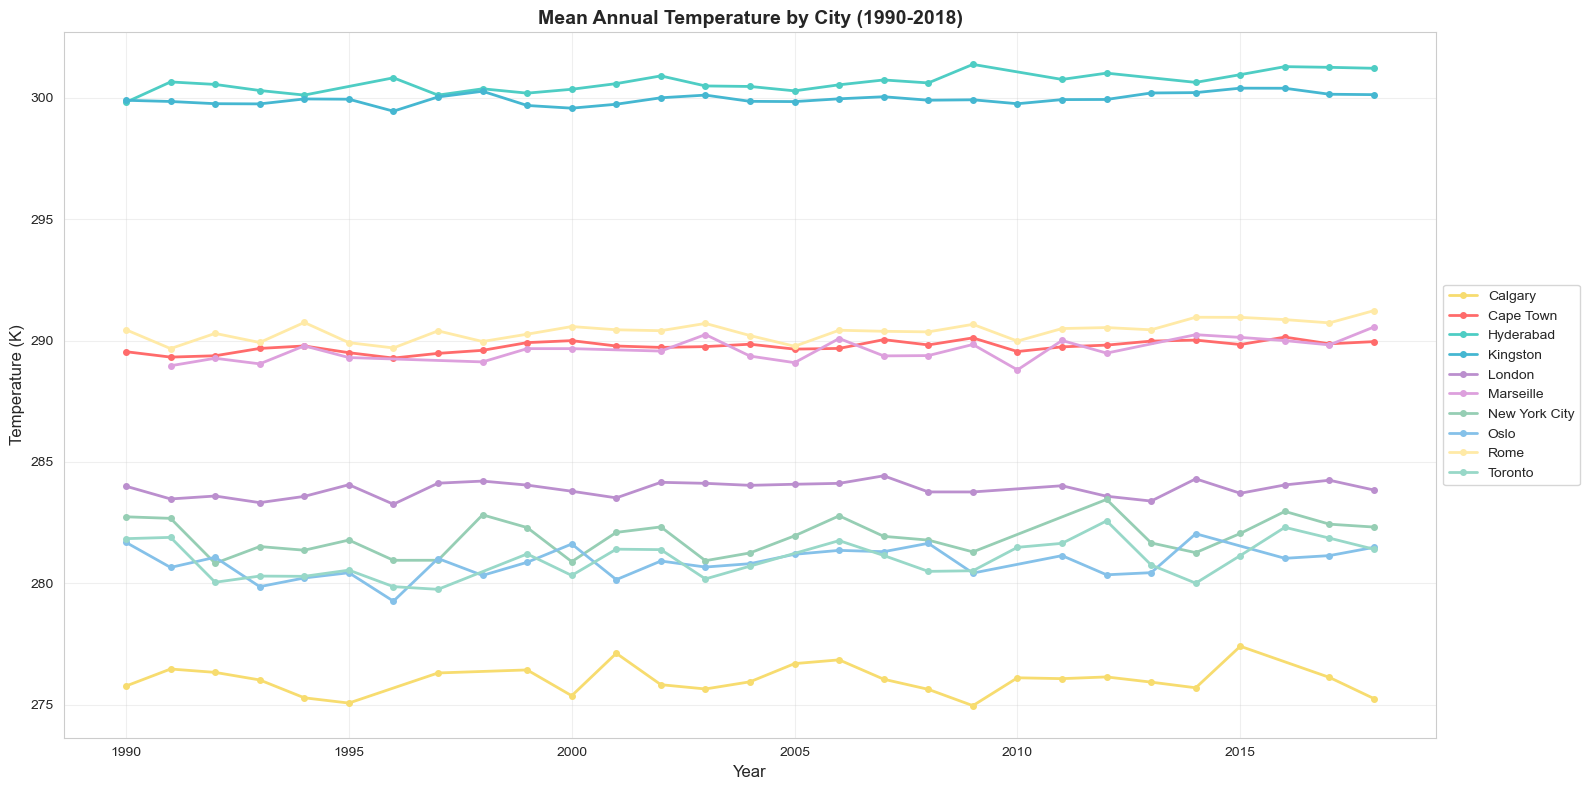


📊 Why important? Shows temperature differences due to latitude and geography.
📈 What it shows: Hyderabad and Kingston are warmest; Calgary and Oslo are coldest.


In [4]:
# Temperature Time Series - All Cities
fig, ax = plt.subplots(figsize=(16, 8))

for city in sorted(df['city'].unique()):
    city_data = df[df['city'] == city]
    ax.plot(city_data['year'], city_data['temp_mean_K'], 
            label=city, color=CITY_COLORS[city], linewidth=2, marker='o', markersize=4)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Temperature (K)', fontsize=12)
ax.set_title('Mean Annual Temperature by City (1990-2018)', fontsize=14, fontweight='bold')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Why important? Shows temperature differences due to latitude and geography.")
print("📈 What it shows: Hyderabad and Kingston are warmest; Calgary and Oslo are coldest.")

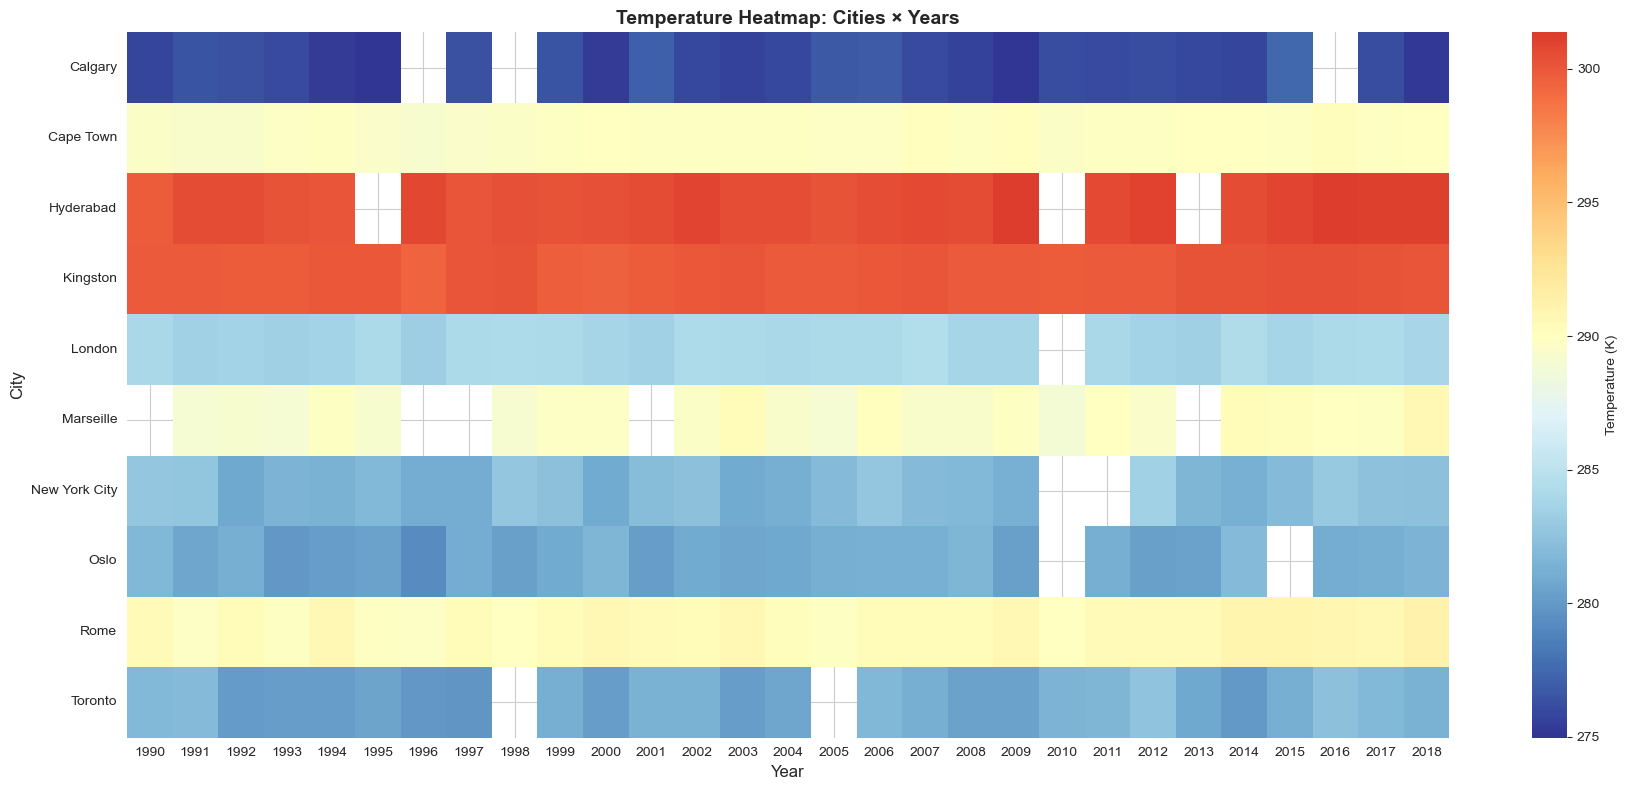


📊 Why important? Visual pattern shows warming trends and seasonal patterns.


In [5]:
# Temperature Heatmap - All Cities Over Time
temp_pivot = df.pivot(index='city', columns='year', values='temp_mean_K')

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(temp_pivot, annot=False, cmap='RdYlBu_r', center=290, 
            cbar_kws={'label': 'Temperature (K)'}, ax=ax)
ax.set_title('Temperature Heatmap: Cities × Years', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('City', fontsize=12)

plt.tight_layout()
plt.show()

print("\n📊 Why important? Visual pattern shows warming trends and seasonal patterns.")

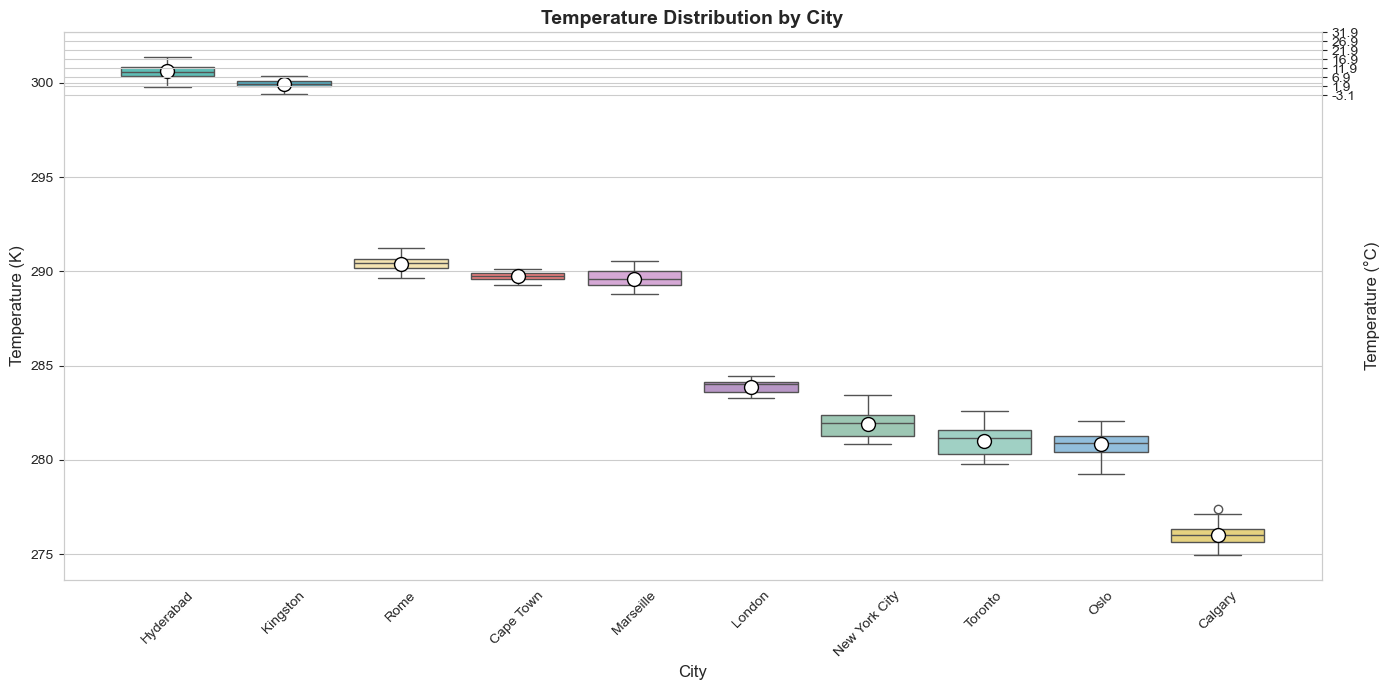


📊 Why important? Shows temperature variability within each city.
📈 What it shows: Clear latitudinal temperature gradient from warm to cold cities.


In [6]:
# Temperature Distribution by City (Box Plot)
fig, ax = plt.subplots(figsize=(14, 7))

# Sort cities by mean temperature
city_order = df.groupby('city')['temp_mean_K'].mean().sort_values(ascending=False).index

sns.boxplot(x='city', y='temp_mean_K', data=df, order=city_order,
            palette=CITY_COLORS, ax=ax)

# Add mean points
means = df.groupby('city')['temp_mean_K'].mean()
for i, city in enumerate(city_order):
    ax.scatter(i, means[city], color='white', s=100, zorder=5, edgecolors='black')

ax.set_xlabel('City', fontsize=12)
ax.set_ylabel('Temperature (K)', fontsize=12)
ax.set_title('Temperature Distribution by City', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)

# Convert to Celsius for reference
ax2 = ax.twinx()
ax2.set_ylabel('Temperature (°C)', fontsize=12)
ticks = ax.get_yticks()
ax2.set_yticks(ticks)
ax2.set_yticklabels([f'{t - 273.15:.1f}' for t in ticks])

plt.tight_layout()
plt.show()

print("\n📊 Why important? Shows temperature variability within each city.")
print("📈 What it shows: Clear latitudinal temperature gradient from warm to cold cities.")

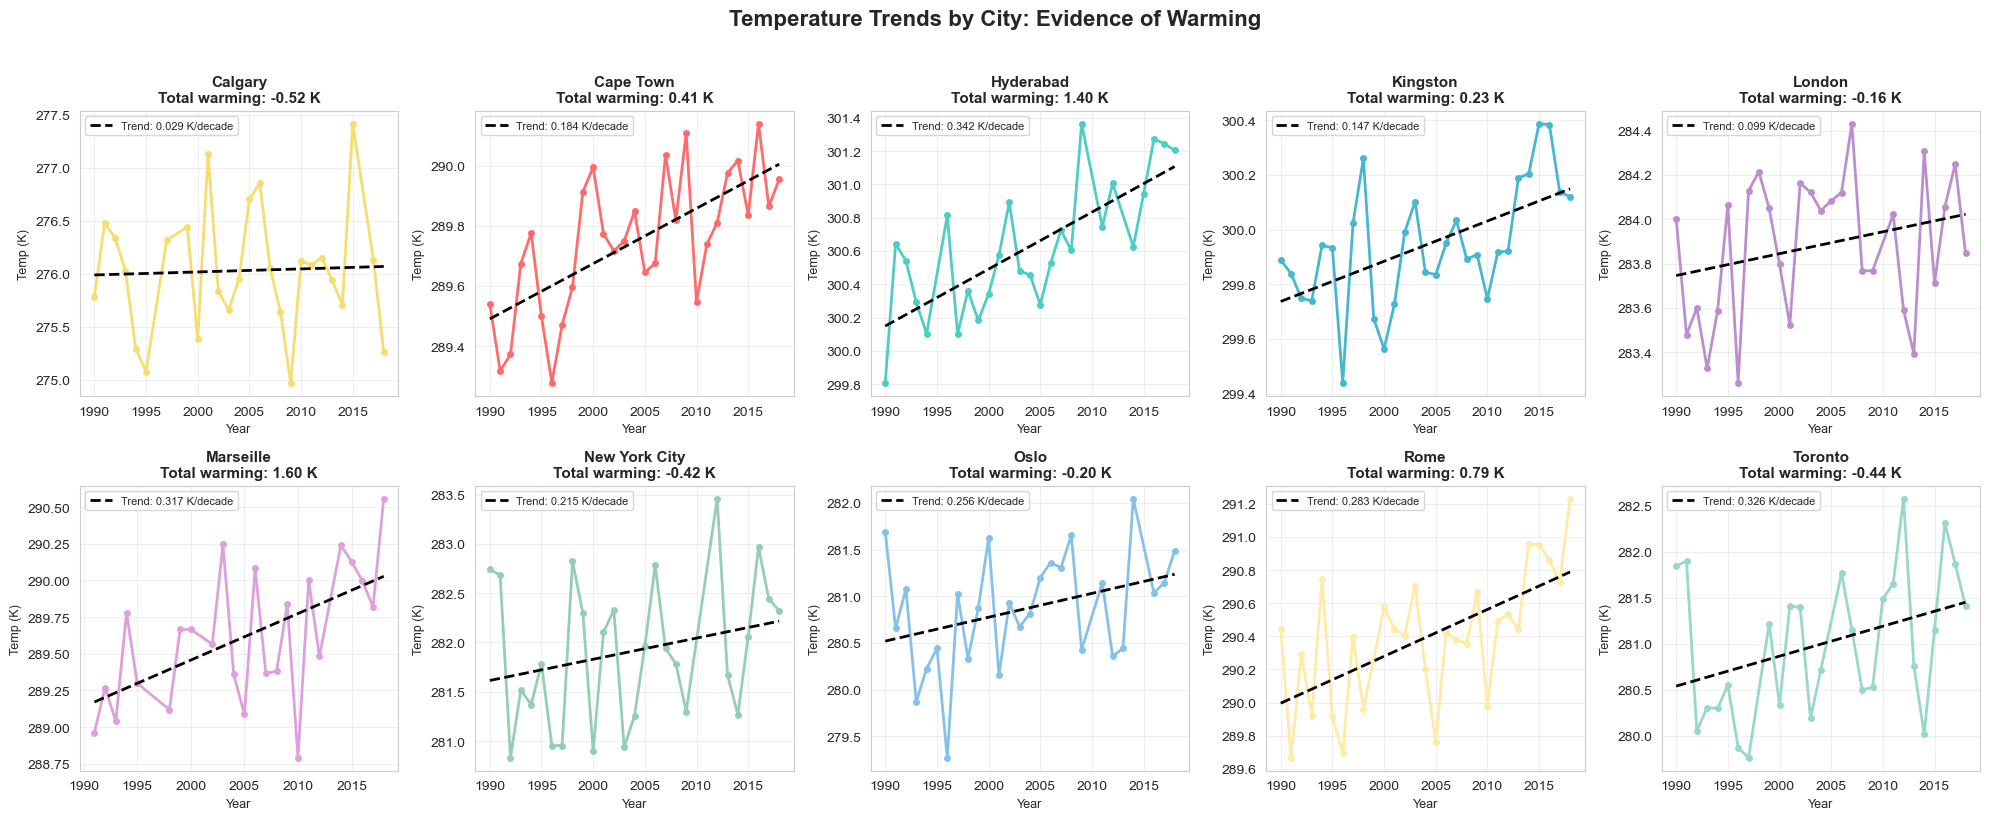


📊 Why important? Quantifies warming trends across different geographies.


In [7]:
# Temperature Change Over Time - Warming Trends
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

cities = sorted(df['city'].unique())

for i, city in enumerate(cities):
    ax = axes[i]
    city_data = df[df['city'] == city]
    
    # Plot temperature
    ax.plot(city_data['year'], city_data['temp_mean_K'], 
            color=CITY_COLORS[city], linewidth=2, marker='o', markersize=4)
    
    # Add trend line
    z = np.polyfit(city_data['year'], city_data['temp_mean_K'], 1)
    p = np.poly1d(z)
    ax.plot(city_data['year'], p(city_data['year']), '--', 
            color='black', linewidth=2, label=f'Trend: {z[0]*10:.3f} K/decade')
    
    # Calculate warming
    warming = city_data['temp_mean_K'].iloc[-1] - city_data['temp_mean_K'].iloc[0]
    
    ax.set_title(f'{city}\nTotal warming: {warming:.2f} K', fontsize=11, fontweight='bold')
    ax.set_xlabel('Year', fontsize=9)
    ax.set_ylabel('Temp (K)', fontsize=9)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.3)

fig.suptitle('Temperature Trends by City: Evidence of Warming', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 Why important? Quantifies warming trends across different geographies.")

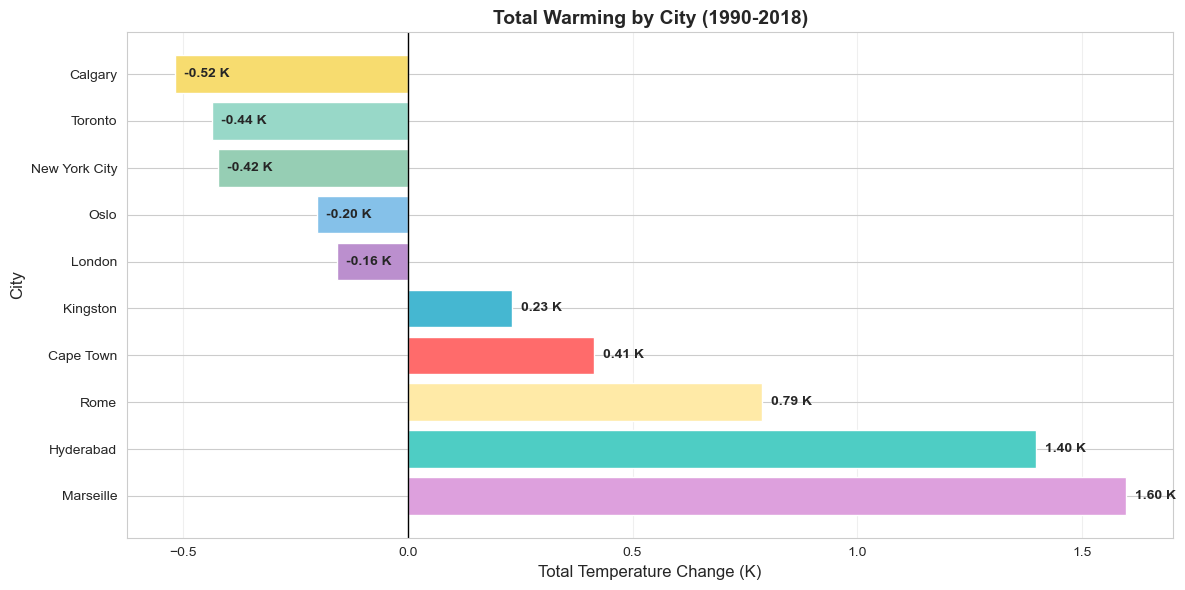


📊 Why important? Shows which cities warmed most.
📈 Mean warming: 0.27 K
📈 Hottest warming: Marseille (1.60 K)


In [8]:
# Warming Comparison Bar Chart
warming_data = []
for city in df['city'].unique():
    city_data = df[df['city'] == city].sort_values('year')
    warming = city_data['temp_mean_K'].iloc[-1] - city_data['temp_mean_K'].iloc[0]
    z = np.polyfit(city_data['year'], city_data['temp_mean_K'], 1)
    warming_data.append({
        'city': city,
        'total_warming': warming,
        'warming_per_decade': z[0] * 10
    })

warming_df = pd.DataFrame(warming_data).sort_values('total_warming', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
colors = [CITY_COLORS[c] for c in warming_df['city']]
bars = ax.barh(warming_df['city'], warming_df['total_warming'], color=colors, edgecolor='white')

# Add value labels
for bar, (idx, row) in zip(bars, warming_df.iterrows()):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{row["total_warming"]:.2f} K', ha='left', va='center', fontsize=10, fontweight='bold')

ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Total Temperature Change (K)', fontsize=12)
ax.set_ylabel('City', fontsize=12)
ax.set_title('Total Warming by City (1990-2018)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print(f"\n📊 Why important? Shows which cities warmed most.")
print(f"📈 Mean warming: {warming_df['total_warming'].mean():.2f} K")
print(f"📈 Hottest warming: {warming_df.iloc[0]['city']} ({warming_df.iloc[0]['total_warming']:.2f} K)")

## 3. Precipitation Patterns

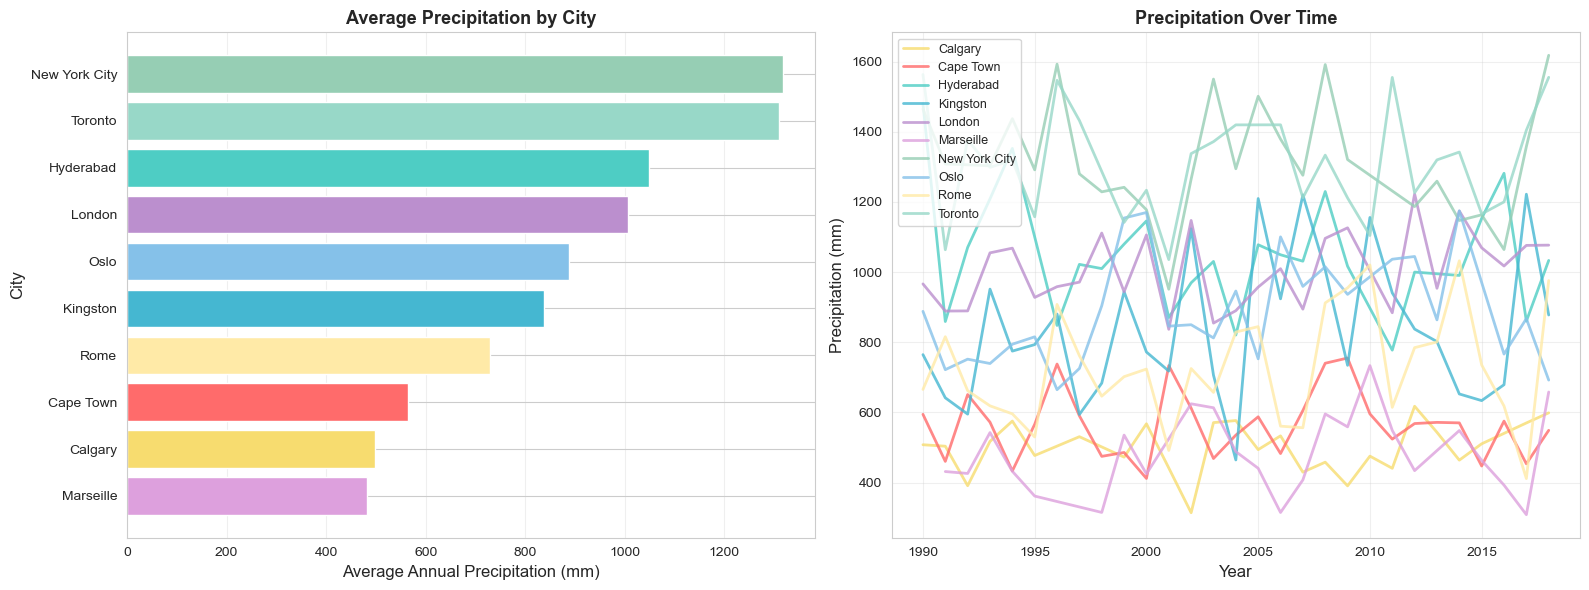


📊 Why important? Shows climate diversity - monsoon vs Mediterranean vs temperate.
📈 What it shows: Hyderabad has highest rainfall (monsoon), Cape Town lowest.


In [9]:
# Precipitation Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of average precipitation
ax1 = axes[0]
precip_means = df.groupby('city')['precip_total_mm'].mean().sort_values(ascending=True)
colors = [CITY_COLORS[c] for c in precip_means.index]
ax1.barh(precip_means.index, precip_means.values, color=colors, edgecolor='white')
ax1.set_xlabel('Average Annual Precipitation (mm)', fontsize=12)
ax1.set_ylabel('City', fontsize=12)
ax1.set_title('Average Precipitation by City', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# Time series
ax2 = axes[1]
for city in sorted(df['city'].unique()):
    city_data = df[df['city'] == city]
    ax2.plot(city_data['year'], city_data['precip_total_mm'], 
            label=city, color=CITY_COLORS[city], linewidth=2, alpha=0.8)
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Precipitation (mm)', fontsize=12)
ax2.set_title('Precipitation Over Time', fontsize=13, fontweight='bold')
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Why important? Shows climate diversity - monsoon vs Mediterranean vs temperate.")
print("📈 What it shows: Hyderabad has highest rainfall (monsoon), Cape Town lowest.")

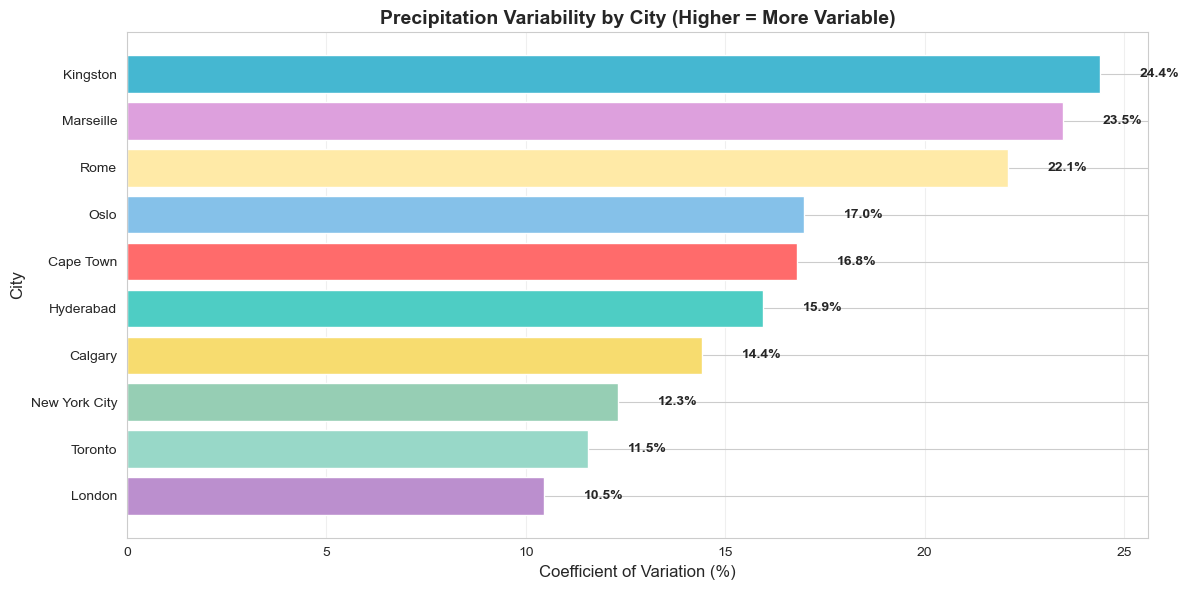


📊 Why important? Shows climate stability - some cities have unpredictable rainfall.


In [10]:
# Precipitation Variability (Coefficient of Variation)
precip_cv = df.groupby('city')['precip_total_mm'].agg(['std', 'mean'])
precip_cv['cv'] = precip_cv['std'] / precip_cv['mean'] * 100
precip_cv = precip_cv.sort_values('cv', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
colors = [CITY_COLORS[c] for c in precip_cv.index]
ax.barh(precip_cv.index, precip_cv['cv'], color=colors, edgecolor='white')

for i, (city, row) in enumerate(precip_cv.iterrows()):
    ax.text(row['cv'] + 1, i, f'{row["cv"]:.1f}%', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Coefficient of Variation (%)', fontsize=12)
ax.set_ylabel('City', fontsize=12)
ax.set_title('Precipitation Variability by City (Higher = More Variable)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n📊 Why important? Shows climate stability - some cities have unpredictable rainfall.")

## 4. Development & Emissions Comparison

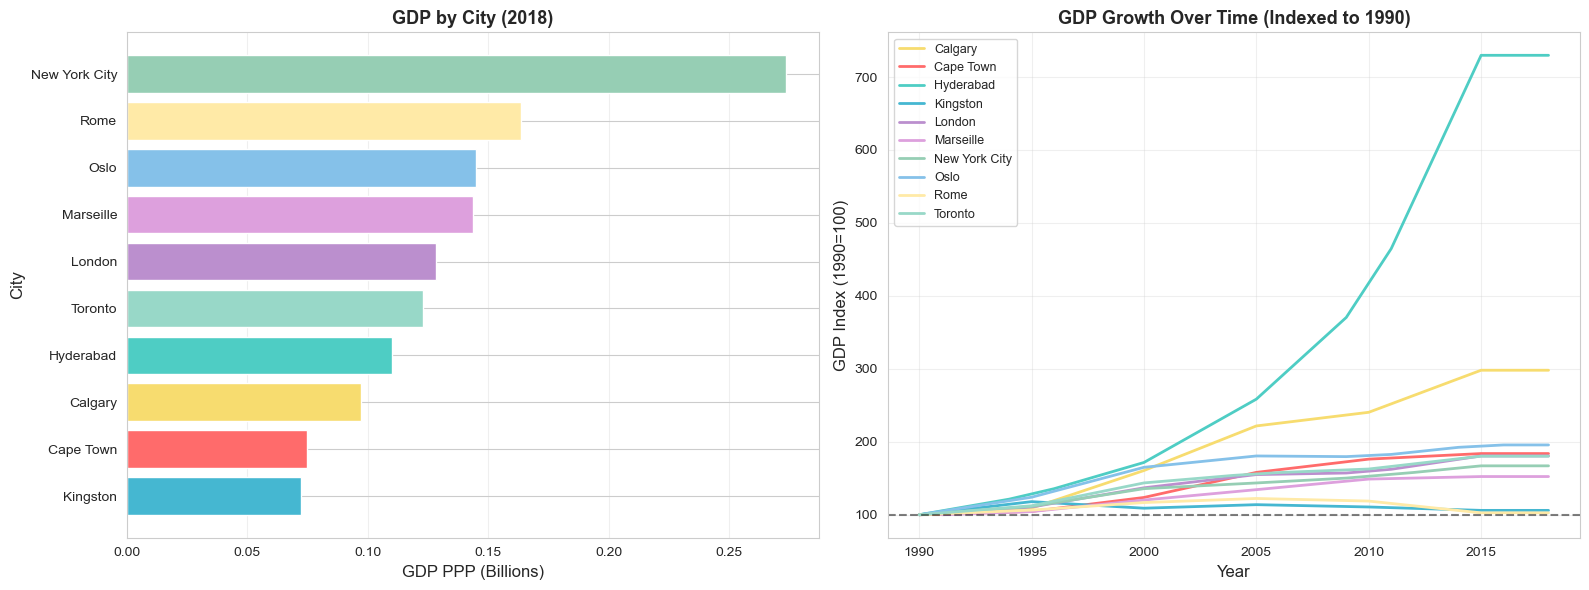


📊 Why important? Shows economic development trajectories.


In [11]:
# GDP Comparison Across Cities
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Current GDP (2018)
ax1 = axes[0]
gdp_2018 = df[df['year'] == 2018][['city', 'gdp_ppp']].sort_values('gdp_ppp', ascending=True)
colors = [CITY_COLORS[c] for c in gdp_2018['city']]
ax1.barh(gdp_2018['city'], gdp_2018['gdp_ppp'] / 1e9, color=colors, edgecolor='white')
ax1.set_xlabel('GDP PPP (Billions)', fontsize=12)
ax1.set_ylabel('City', fontsize=12)
ax1.set_title('GDP by City (2018)', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# GDP growth over time
ax2 = axes[1]
for city in sorted(df['city'].unique()):
    city_data = df[df['city'] == city]
    gdp_indexed = city_data.set_index('year')['gdp_ppp'] / city_data.set_index('year')['gdp_ppp'].iloc[0] * 100
    ax2.plot(gdp_indexed.index, gdp_indexed.values, 
            label=city, color=CITY_COLORS[city], linewidth=2)
ax2.axhline(100, color='black', linestyle='--', alpha=0.5)
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('GDP Index (1990=100)', fontsize=12)
ax2.set_title('GDP Growth Over Time (Indexed to 1990)', fontsize=13, fontweight='bold')
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Why important? Shows economic development trajectories.")

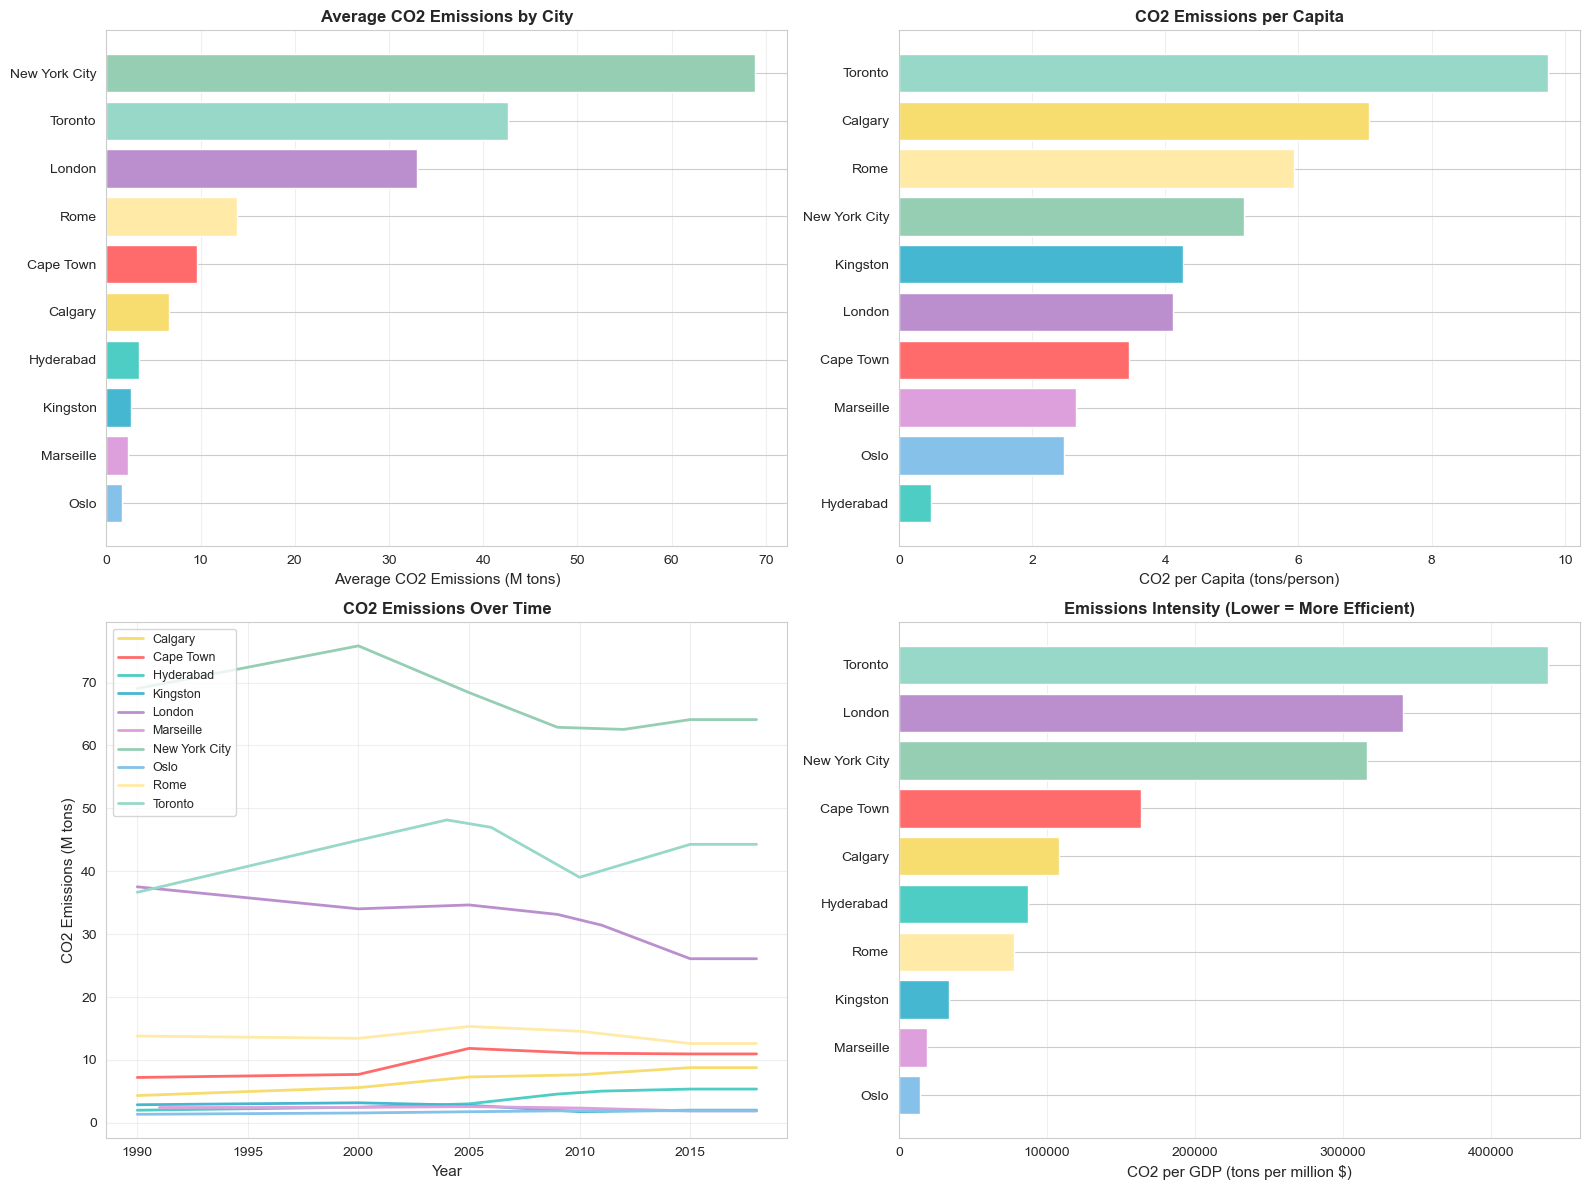


📊 Why important? Shows emissions patterns and efficiency differences.
📈 What it shows: New York emits most total; developing cities more efficient.


In [12]:
# CO2 Emissions Comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Average emissions by city
ax1 = axes[0, 0]
emissions_mean = df.groupby('city')['co2_emissions_ton'].mean().sort_values(ascending=True) / 1e6
colors = [CITY_COLORS[c] for c in emissions_mean.index]
ax1.barh(emissions_mean.index, emissions_mean.values, color=colors, edgecolor='white')
ax1.set_xlabel('Average CO2 Emissions (M tons)', fontsize=11)
ax1.set_title('Average CO2 Emissions by City', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# Emissions per capita
ax2 = axes[0, 1]
df['co2_per_cap'] = df['co2_emissions_ton'] / df['population']
emissions_pc = df.groupby('city')['co2_per_cap'].mean().sort_values(ascending=True)
colors = [CITY_COLORS[c] for c in emissions_pc.index]
ax2.barh(emissions_pc.index, emissions_pc.values, color=colors, edgecolor='white')
ax2.set_xlabel('CO2 per Capita (tons/person)', fontsize=11)
ax2.set_title('CO2 Emissions per Capita', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

# Emissions over time
ax3 = axes[1, 0]
for city in sorted(df['city'].unique()):
    city_data = df[df['city'] == city]
    ax3.plot(city_data['year'], city_data['co2_emissions_ton'] / 1e6, 
            label=city, color=CITY_COLORS[city], linewidth=2)
ax3.set_xlabel('Year', fontsize=11)
ax3.set_ylabel('CO2 Emissions (M tons)', fontsize=11)
ax3.set_title('CO2 Emissions Over Time', fontsize=12, fontweight='bold')
ax3.legend(loc='upper left', fontsize=9)
ax3.grid(True, alpha=0.3)

# Emissions intensity (per GDP)
ax4 = axes[1, 1]
df['co2_per_gdp'] = df['co2_emissions_ton'] / df['gdp_ppp']
emissions_intensity = df.groupby('city')['co2_per_gdp'].mean().sort_values(ascending=True)
colors = [CITY_COLORS[c] for c in emissions_intensity.index]
ax4.barh(emissions_intensity.index, emissions_intensity.values * 1e6, color=colors, edgecolor='white')
ax4.set_xlabel('CO2 per GDP (tons per million $)', fontsize=11)
ax4.set_title('Emissions Intensity (Lower = More Efficient)', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n📊 Why important? Shows emissions patterns and efficiency differences.")
print("📈 What it shows: New York emits most total; developing cities more efficient.")

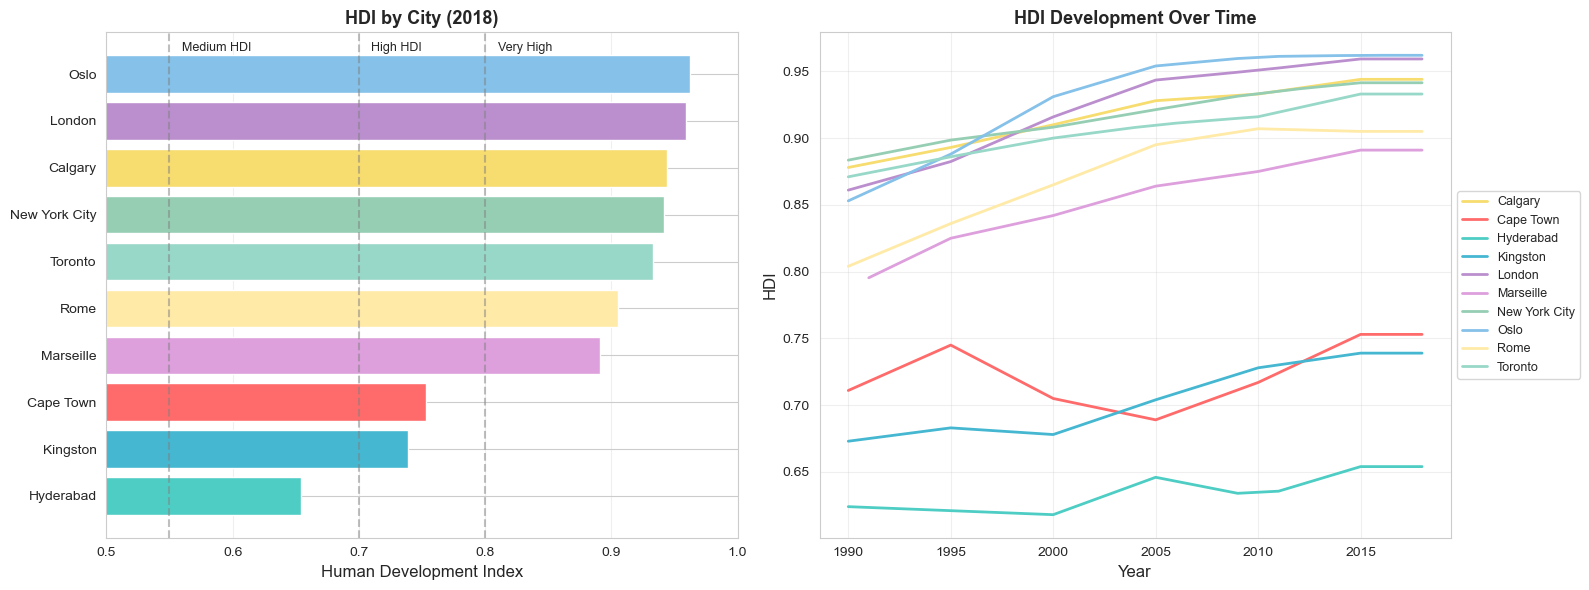


📊 Why important? Shows human development levels across cities.


In [13]:
# HDI Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Current HDI
ax1 = axes[0]
hdi_2018 = df[df['year'] == 2018][['city', 'hdi']].sort_values('hdi', ascending=True)
colors = [CITY_COLORS[c] for c in hdi_2018['city']]
bars = ax1.barh(hdi_2018['city'], hdi_2018['hdi'], color=colors, edgecolor='white')

# Add HDI category regions
ax1.axvline(0.55, color='gray', linestyle='--', alpha=0.5)
ax1.axvline(0.70, color='gray', linestyle='--', alpha=0.5)
ax1.axvline(0.80, color='gray', linestyle='--', alpha=0.5)
ax1.text(0.56, 9.5, 'Medium HDI', fontsize=9)
ax1.text(0.71, 9.5, 'High HDI', fontsize=9)
ax1.text(0.81, 9.5, 'Very High', fontsize=9)

ax1.set_xlabel('Human Development Index', fontsize=12)
ax1.set_title('HDI by City (2018)', fontsize=13, fontweight='bold')
ax1.set_xlim(0.5, 1.0)
ax1.grid(True, alpha=0.3, axis='x')

# HDI over time
ax2 = axes[1]
for city in sorted(df['city'].unique()):
    city_data = df[df['city'] == city]
    ax2.plot(city_data['year'], city_data['hdi'], 
            label=city, color=CITY_COLORS[city], linewidth=2)
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('HDI', fontsize=12)
ax2.set_title('HDI Development Over Time', fontsize=13, fontweight='bold')
ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Why important? Shows human development levels across cities.")

## 5. Temperature vs Development Relationships

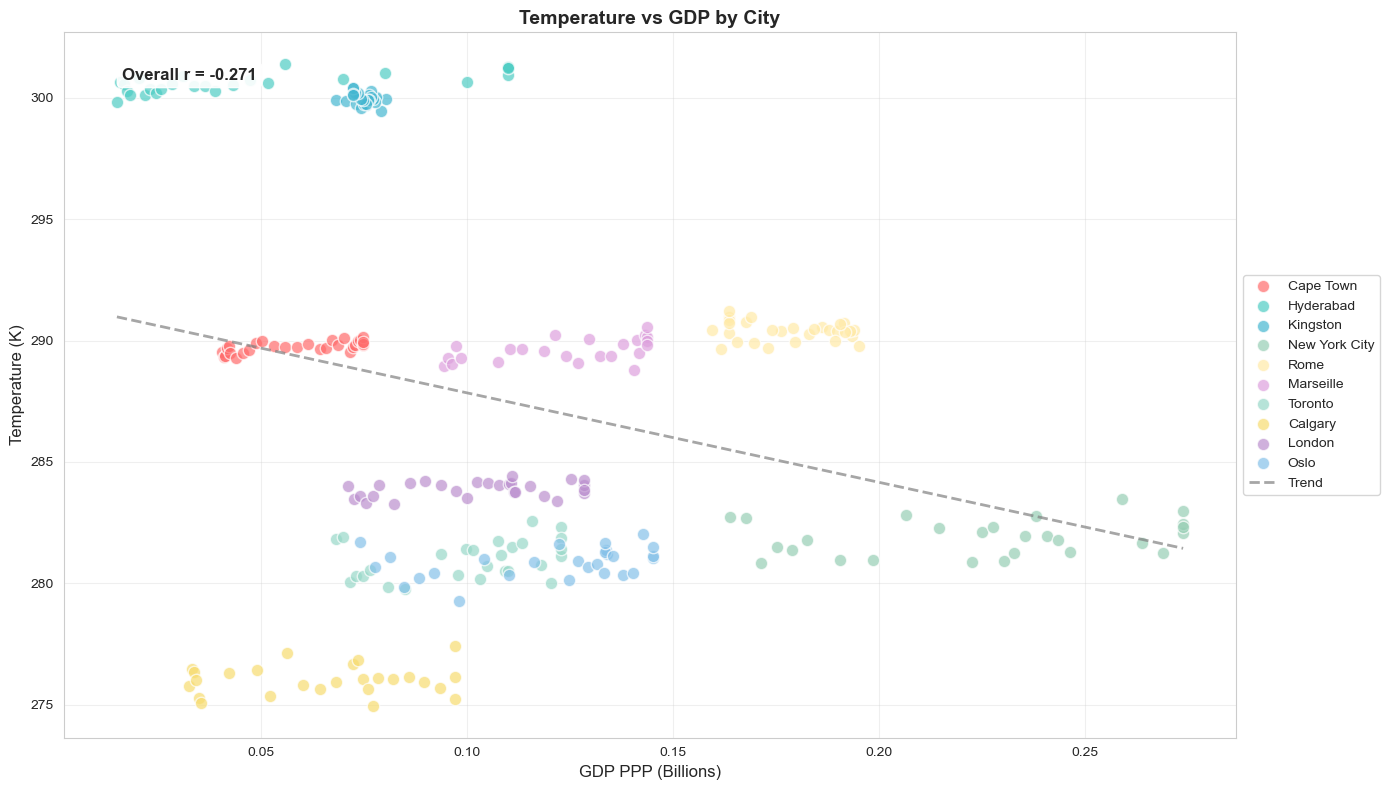


📊 Why important? Explores temperature-development relationship.


In [14]:
# Temperature vs GDP per City
fig, ax = plt.subplots(figsize=(14, 8))

for city in df['city'].unique():
    city_data = df[df['city'] == city]
    ax.scatter(city_data['gdp_ppp'] / 1e9, city_data['temp_mean_K'], 
              label=city, color=CITY_COLORS[city], s=80, alpha=0.7, edgecolors='white')

# Add regression line
z = np.polyfit(df['gdp_ppp'] / 1e9, df['temp_mean_K'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['gdp_ppp'].min() / 1e9, df['gdp_ppp'].max() / 1e9, 100)
ax.plot(x_line, p(x_line), '--', color='gray', linewidth=2, alpha=0.7, label='Trend')

corr = df['temp_mean_K'].corr(df['gdp_ppp'])
ax.text(0.05, 0.95, f'Overall r = {corr:.3f}', transform=ax.transAxes, fontsize=12,
        verticalalignment='top', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

ax.set_xlabel('GDP PPP (Billions)', fontsize=12)
ax.set_ylabel('Temperature (K)', fontsize=12)
ax.set_title('Temperature vs GDP by City', fontsize=14, fontweight='bold')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Why important? Explores temperature-development relationship.")

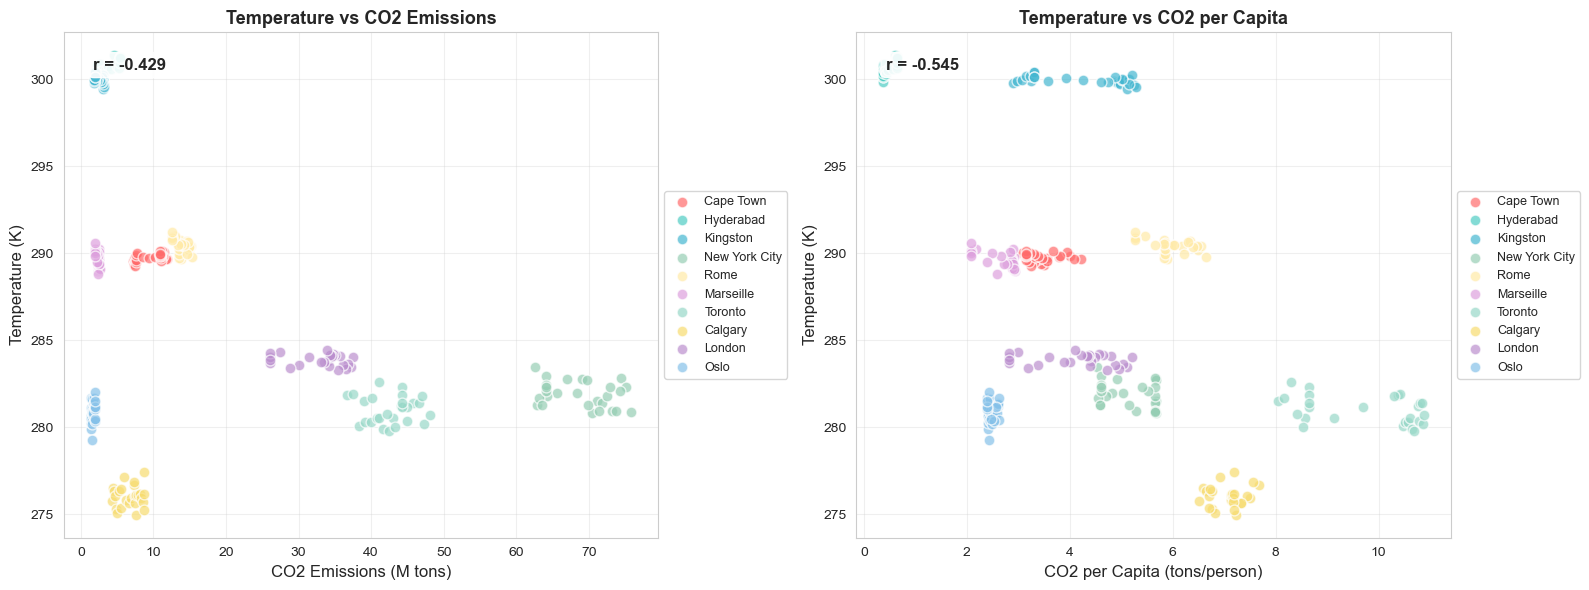


📊 Why important? Explores emissions-temperature relationship across geographies.
📈 Note: Strong negative correlation due to latitudinal effects.


In [15]:
# Temperature vs Emissions by City
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter with city colors
ax1 = axes[0]
for city in df['city'].unique():
    city_data = df[df['city'] == city]
    ax1.scatter(city_data['co2_emissions_ton'] / 1e6, city_data['temp_mean_K'], 
               label=city, color=CITY_COLORS[city], s=60, alpha=0.7, edgecolors='white')

corr = df['temp_mean_K'].corr(df['co2_emissions_ton'])
ax1.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax1.transAxes, fontsize=12,
        verticalalignment='top', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
ax1.set_xlabel('CO2 Emissions (M tons)', fontsize=12)
ax1.set_ylabel('Temperature (K)', fontsize=12)
ax1.set_title('Temperature vs CO2 Emissions', fontsize=13, fontweight='bold')
ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
ax1.grid(True, alpha=0.3)

# Emissions per capita vs Temperature
ax2 = axes[1]
for city in df['city'].unique():
    city_data = df[df['city'] == city]
    ax2.scatter(city_data['co2_per_cap'], city_data['temp_mean_K'], 
               label=city, color=CITY_COLORS[city], s=60, alpha=0.7, edgecolors='white')

corr_pc = df['temp_mean_K'].corr(df['co2_per_cap'])
ax2.text(0.05, 0.95, f'r = {corr_pc:.3f}', transform=ax2.transAxes, fontsize=12,
        verticalalignment='top', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
ax2.set_xlabel('CO2 per Capita (tons/person)', fontsize=12)
ax2.set_ylabel('Temperature (K)', fontsize=12)
ax2.set_title('Temperature vs CO2 per Capita', fontsize=13, fontweight='bold')
ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Why important? Explores emissions-temperature relationship across geographies.")
print("📈 Note: Strong negative correlation due to latitudinal effects.")

## 6. Correlation Analysis

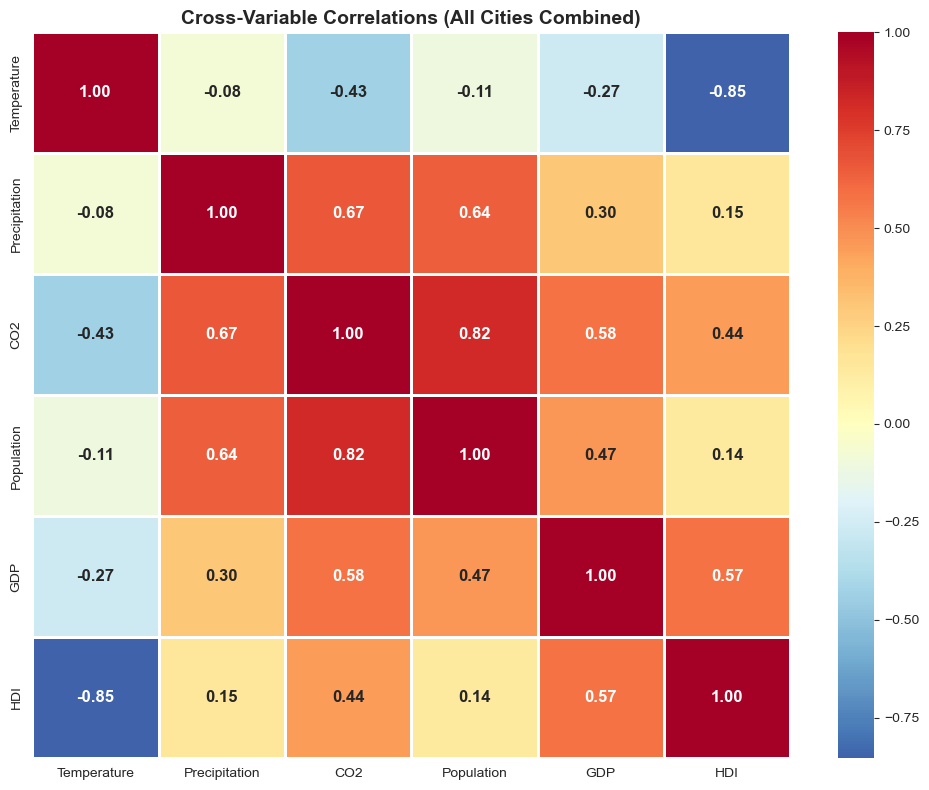


📊 Why important? Shows relationships between all variables.


In [16]:
# Cross-City Correlation Matrix
# Create a pivot table for each variable
vars_to_analyze = ['temp_mean_K', 'precip_total_mm', 'co2_emissions_ton', 'population', 'gdp_ppp', 'hdi']
var_labels = ['Temperature', 'Precipitation', 'CO2', 'Population', 'GDP', 'HDI']

# Calculate correlations between variables across all cities
corr_matrix = df[vars_to_analyze].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu_r', center=0,
            fmt='.2f', linewidths=1, ax=ax,
            xticklabels=var_labels, yticklabels=var_labels,
            annot_kws={'size': 12, 'fontweight': 'bold'})
ax.set_title('Cross-Variable Correlations (All Cities Combined)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Why important? Shows relationships between all variables.")

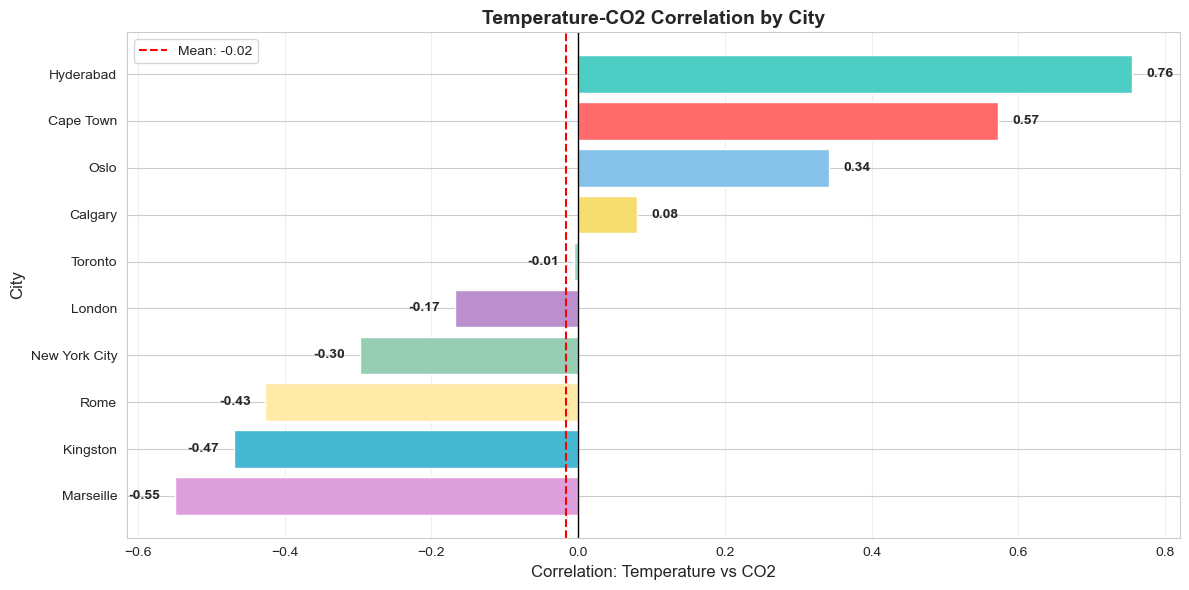


📊 Why important? Shows city-specific temperature-emissions relationships.


In [17]:
# Correlation between Temperature and CO2 by City
city_correlations = []
for city in df['city'].unique():
    city_data = df[df['city'] == city]
    corr = city_data['temp_mean_K'].corr(city_data['co2_emissions_ton'])
    city_correlations.append({
        'city': city,
        'correlation': corr
    })

corr_df = pd.DataFrame(city_correlations).sort_values('correlation', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
colors = [CITY_COLORS[c] for c in corr_df['city']]
bars = ax.barh(corr_df['city'], corr_df['correlation'], color=colors, edgecolor='white')

ax.axvline(0, color='black', linewidth=1)
ax.axvline(corr_df['correlation'].mean(), color='red', linestyle='--', 
           label=f'Mean: {corr_df["correlation"].mean():.2f}')

for bar, (idx, row) in zip(bars, corr_df.iterrows()):
    ax.text(bar.get_width() + 0.02 if bar.get_width() > 0 else bar.get_width() - 0.02,
            bar.get_y() + bar.get_height()/2,
            f'{row["correlation"]:.2f}', ha='left' if bar.get_width() > 0 else 'right',
            va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Correlation: Temperature vs CO2', fontsize=12)
ax.set_ylabel('City', fontsize=12)
ax.set_title('Temperature-CO2 Correlation by City', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n📊 Why important? Shows city-specific temperature-emissions relationships.")

## 7. Climate Clustering

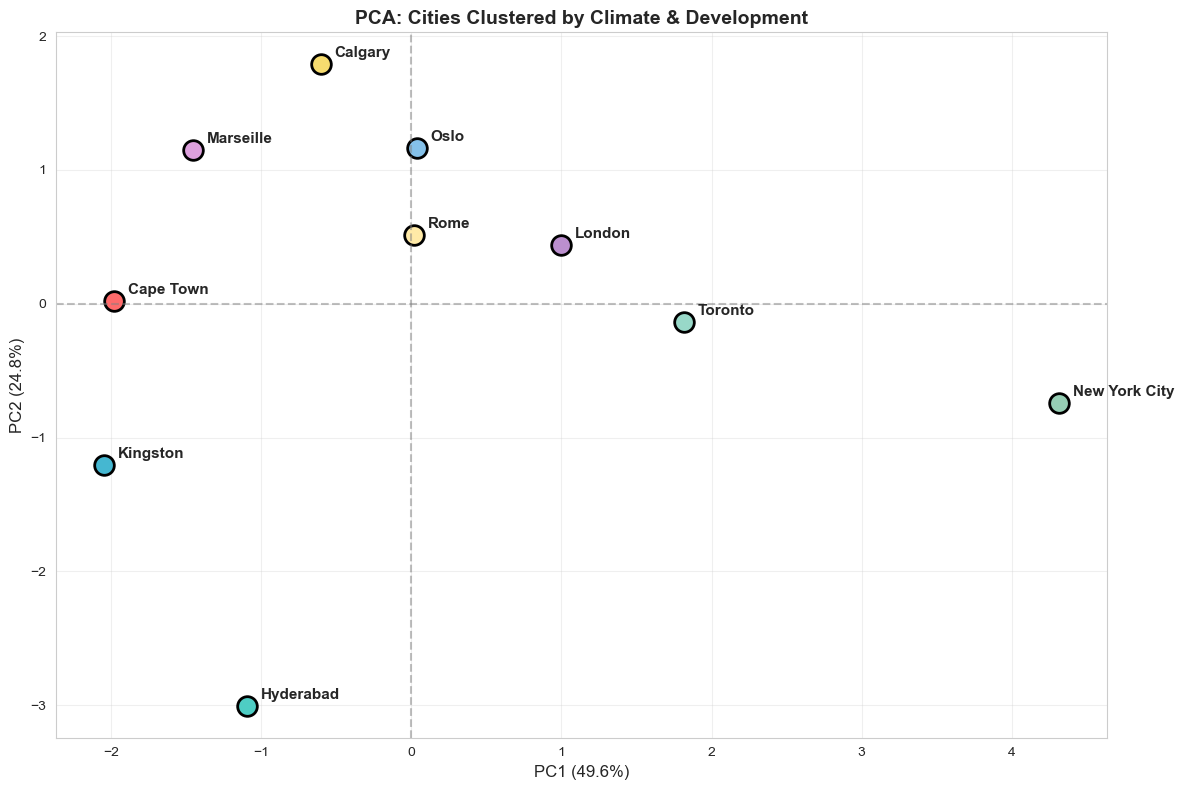


📊 PCA explains 74.4% of variance
📈 What it shows: Cities cluster by geography and development level.


In [18]:
# PCA of Cities Based on All Variables
from sklearn.decomposition import PCA

# Prepare data - use average values per city
city_avg = df.groupby('city').agg({
    'temp_mean_K': 'mean',
    'precip_total_mm': 'mean',
    'co2_emissions_ton': 'mean',
    'population': 'mean',
    'gdp_ppp': 'mean',
    'hdi': 'mean',
    'wind_speed_mean_ms': 'mean'
}).reset_index()

features = ['temp_mean_K', 'precip_total_mm', 'co2_emissions_ton', 'population', 'gdp_ppp', 'hdi', 'wind_speed_mean_ms']
X = city_avg[features]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(12, 8))
for i, city in enumerate(city_avg['city']):
    ax.scatter(pca_result[i, 0], pca_result[i, 1], 
               color=CITY_COLORS[city], s=200, label=city, edgecolors='black', linewidth=2)
    ax.annotate(city, (pca_result[i, 0], pca_result[i, 1]), 
               textcoords="offset points", xytext=(10, 5), fontsize=11, fontweight='bold')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax.set_title('PCA: Cities Clustered by Climate & Development', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"\n📊 PCA explains {sum(pca.explained_variance_ratio_)*100:.1f}% of variance")
print("📈 What it shows: Cities cluster by geography and development level.")

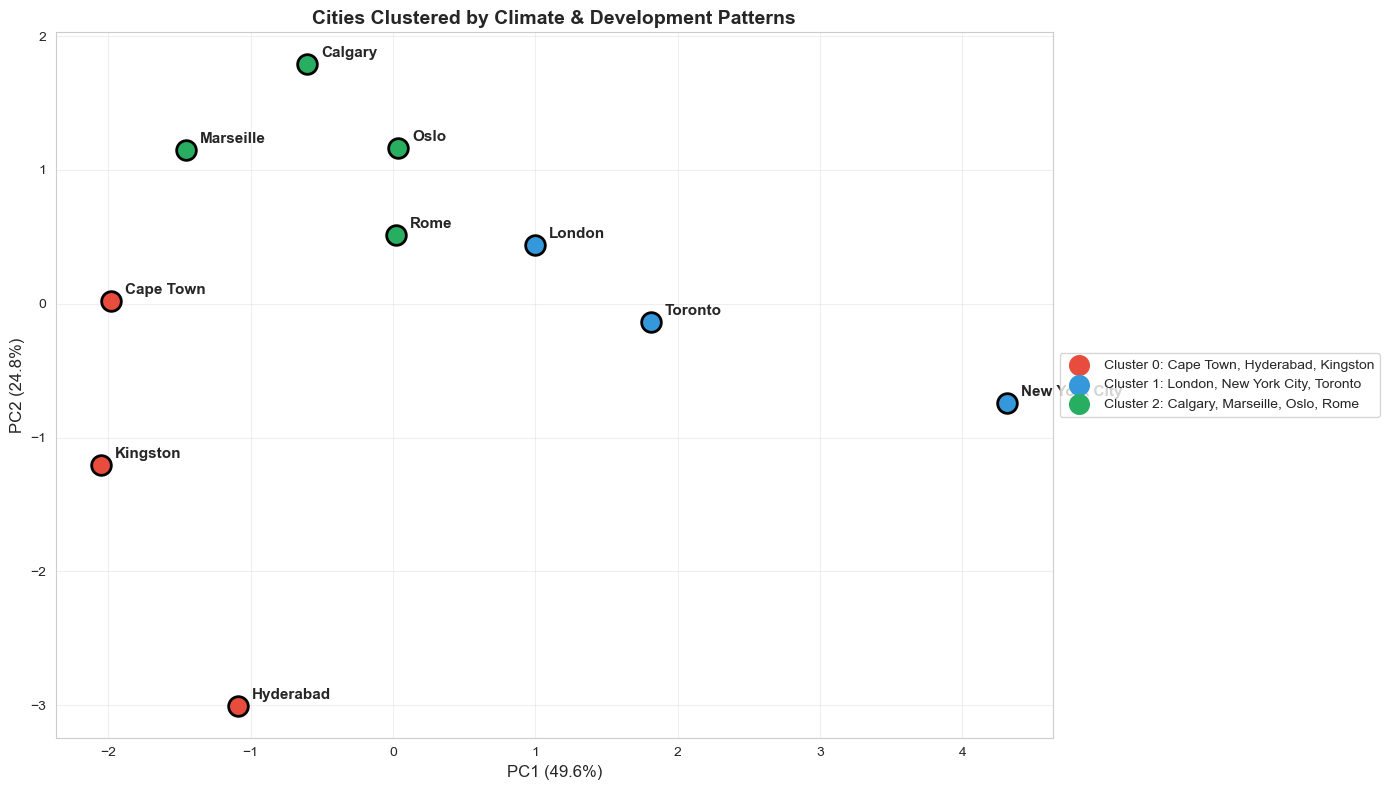


📊 Why important? Groups cities with similar characteristics.


In [19]:
# K-Means Clustering of Cities
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
city_avg['cluster'] = clusters

# Cluster names based on characteristics
cluster_means = city_avg.groupby('cluster')[features].mean()
cluster_info = []
for c in range(3):
    cm = cluster_means.loc[c]
    if cm['temp_mean_K'] > 299:
        name = 'Tropical/Hot'
    elif cm['temp_mean_K'] > 285:
        name = 'Temperate'
    else:
        name = 'Cold/Continental'
    cluster_info.append({'cluster': c, 'name': name})

fig, ax = plt.subplots(figsize=(14, 8))
cluster_colors = ['#E74C3C', '#3498DB', '#27AE60']

for i, city in enumerate(city_avg['city']):
    c = city_avg.loc[city_avg['city'] == city, 'cluster'].values[0]
    ax.scatter(pca_result[i, 0], pca_result[i, 1], 
              color=cluster_colors[c], s=200, 
              edgecolors='black', linewidth=2)
    ax.annotate(city, (pca_result[i, 0], pca_result[i, 1]), 
               textcoords="offset points", xytext=(10, 5), fontsize=11, fontweight='bold')

# Legend
for c in range(3):
    cities_in_cluster = city_avg[city_avg['cluster'] == c]['city'].tolist()
    ax.scatter([], [], color=cluster_colors[c], s=200, label=f'Cluster {c}: {", ".join(cities_in_cluster)}')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax.set_title('Cities Clustered by Climate & Development Patterns', fontsize=14, fontweight='bold')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Why important? Groups cities with similar characteristics.")

## 8. Geographic Patterns

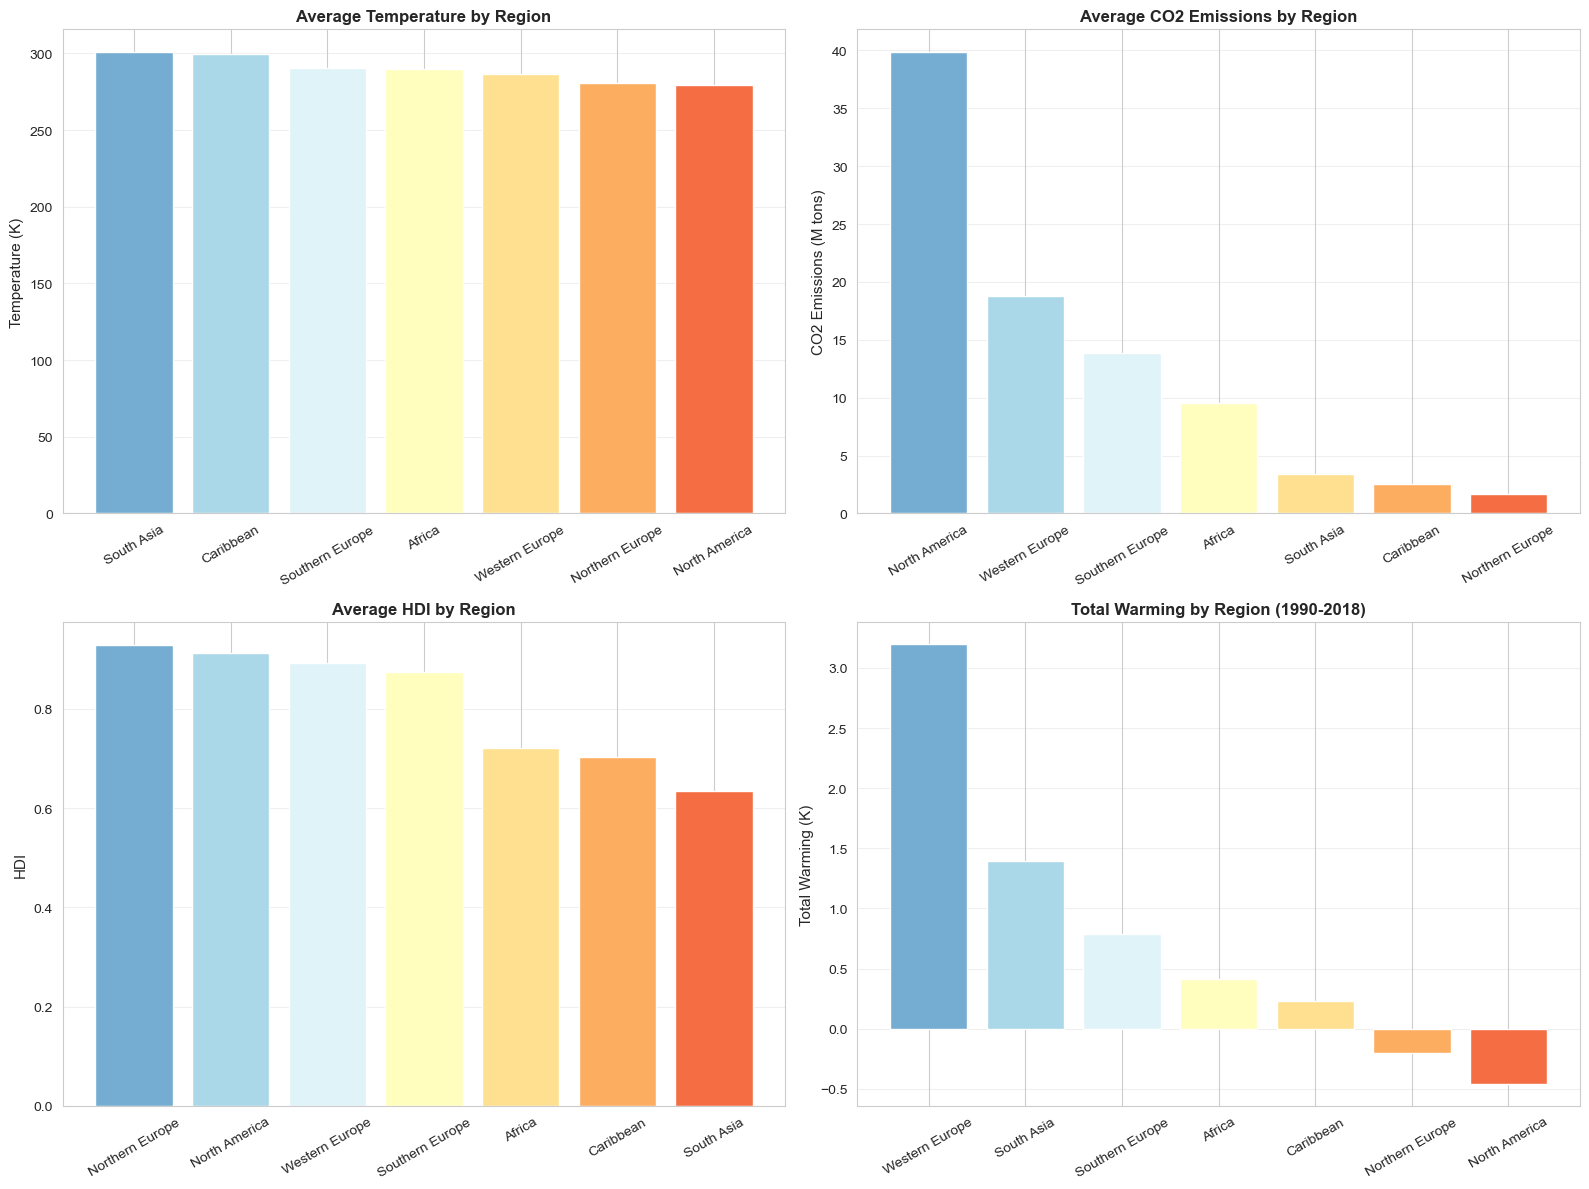


📊 Why important? Shows patterns by geographic region.


In [20]:
# Regional Comparison
# Assign regions
region_map = {
    'Cape Town': 'Africa',
    'Hyderabad': 'South Asia',
    'Kingston': 'Caribbean',
    'New York City': 'North America',
    'Rome': 'Southern Europe',
    'Marseille': 'Western Europe',
    'Toronto': 'North America',
    'Calgary': 'North America',
    'London': 'Western Europe',
    'Oslo': 'Northern Europe'
}

df['region'] = df['city'].map(region_map)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Temperature by region
ax1 = axes[0, 0]
region_temp = df.groupby('region')['temp_mean_K'].mean().sort_values(ascending=False)
region_colors = plt.cm.RdYlBu_r(np.linspace(0.2, 0.8, len(region_temp)))
ax1.bar(region_temp.index, region_temp.values, color=region_colors, edgecolor='white')
ax1.set_ylabel('Temperature (K)', fontsize=11)
ax1.set_title('Average Temperature by Region', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=30)
ax1.grid(True, alpha=0.3, axis='y')

# Emissions by region
ax2 = axes[0, 1]
region_emissions = df.groupby('region')['co2_emissions_ton'].mean().sort_values(ascending=False) / 1e6
ax2.bar(region_emissions.index, region_emissions.values, color=region_colors, edgecolor='white')
ax2.set_ylabel('CO2 Emissions (M tons)', fontsize=11)
ax2.set_title('Average CO2 Emissions by Region', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=30)
ax2.grid(True, alpha=0.3, axis='y')

# HDI by region
ax3 = axes[1, 0]
region_hdi = df.groupby('region')['hdi'].mean().sort_values(ascending=False)
ax3.bar(region_hdi.index, region_hdi.values, color=region_colors, edgecolor='white')
ax3.set_ylabel('HDI', fontsize=11)
ax3.set_title('Average HDI by Region', fontsize=12, fontweight='bold')
ax3.tick_params(axis='x', rotation=30)
ax3.grid(True, alpha=0.3, axis='y')

# Warming by region
ax4 = axes[1, 1]
region_warming = []
for region in df['region'].unique():
    region_data = df[df['region'] == region]
    warming = region_data.groupby('year')['temp_mean_K'].mean()
    if len(warming) > 1:
        region_warming.append({
            'region': region,
            'warming': warming.iloc[-1] - warming.iloc[0]
        })

warming_df = pd.DataFrame(region_warming).sort_values('warming', ascending=False)
ax4.bar(warming_df['region'], warming_df['warming'], color=region_colors, edgecolor='white')
ax4.set_ylabel('Total Warming (K)', fontsize=11)
ax4.set_title('Total Warming by Region (1990-2018)', fontsize=12, fontweight='bold')
ax4.tick_params(axis='x', rotation=30)
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n📊 Why important? Shows patterns by geographic region.")

## 9. Wind & Climate Variability

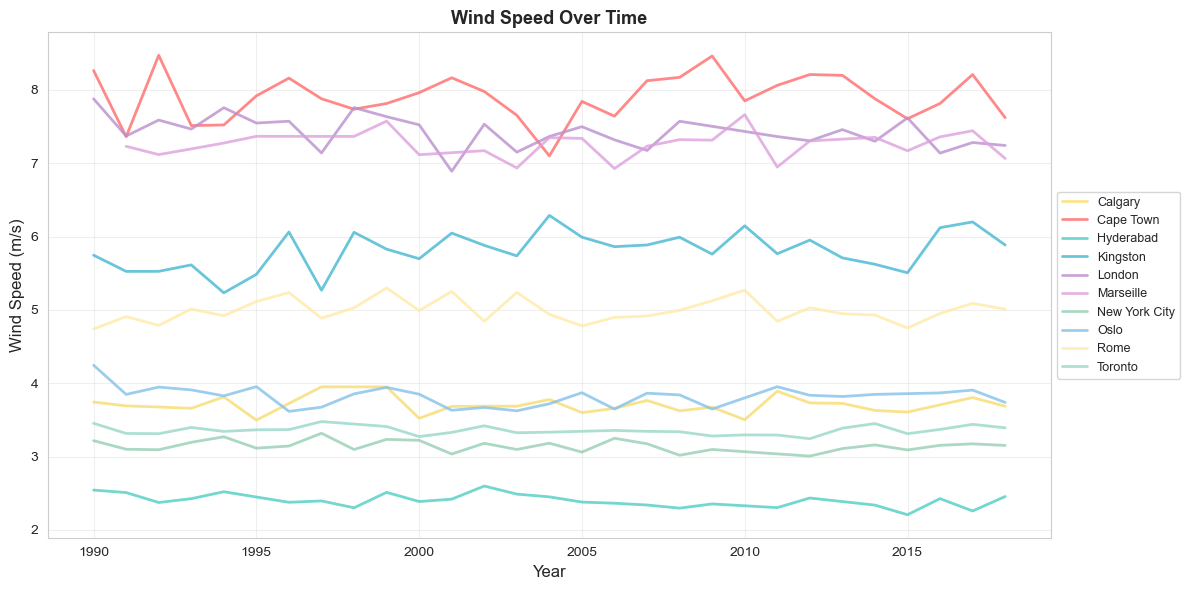

In [21]:
# Wind speed over time
for city in sorted(df['city'].unique()):
    city_data = df[df['city'] == city]
    plt.plot(city_data['year'], city_data['wind_speed_mean_ms'], 
            label=city, color=CITY_COLORS[city], linewidth=2, alpha=0.8)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Wind Speed (m/s)', fontsize=12)
plt.title('Wind Speed Over Time', fontsize=13, fontweight='bold')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


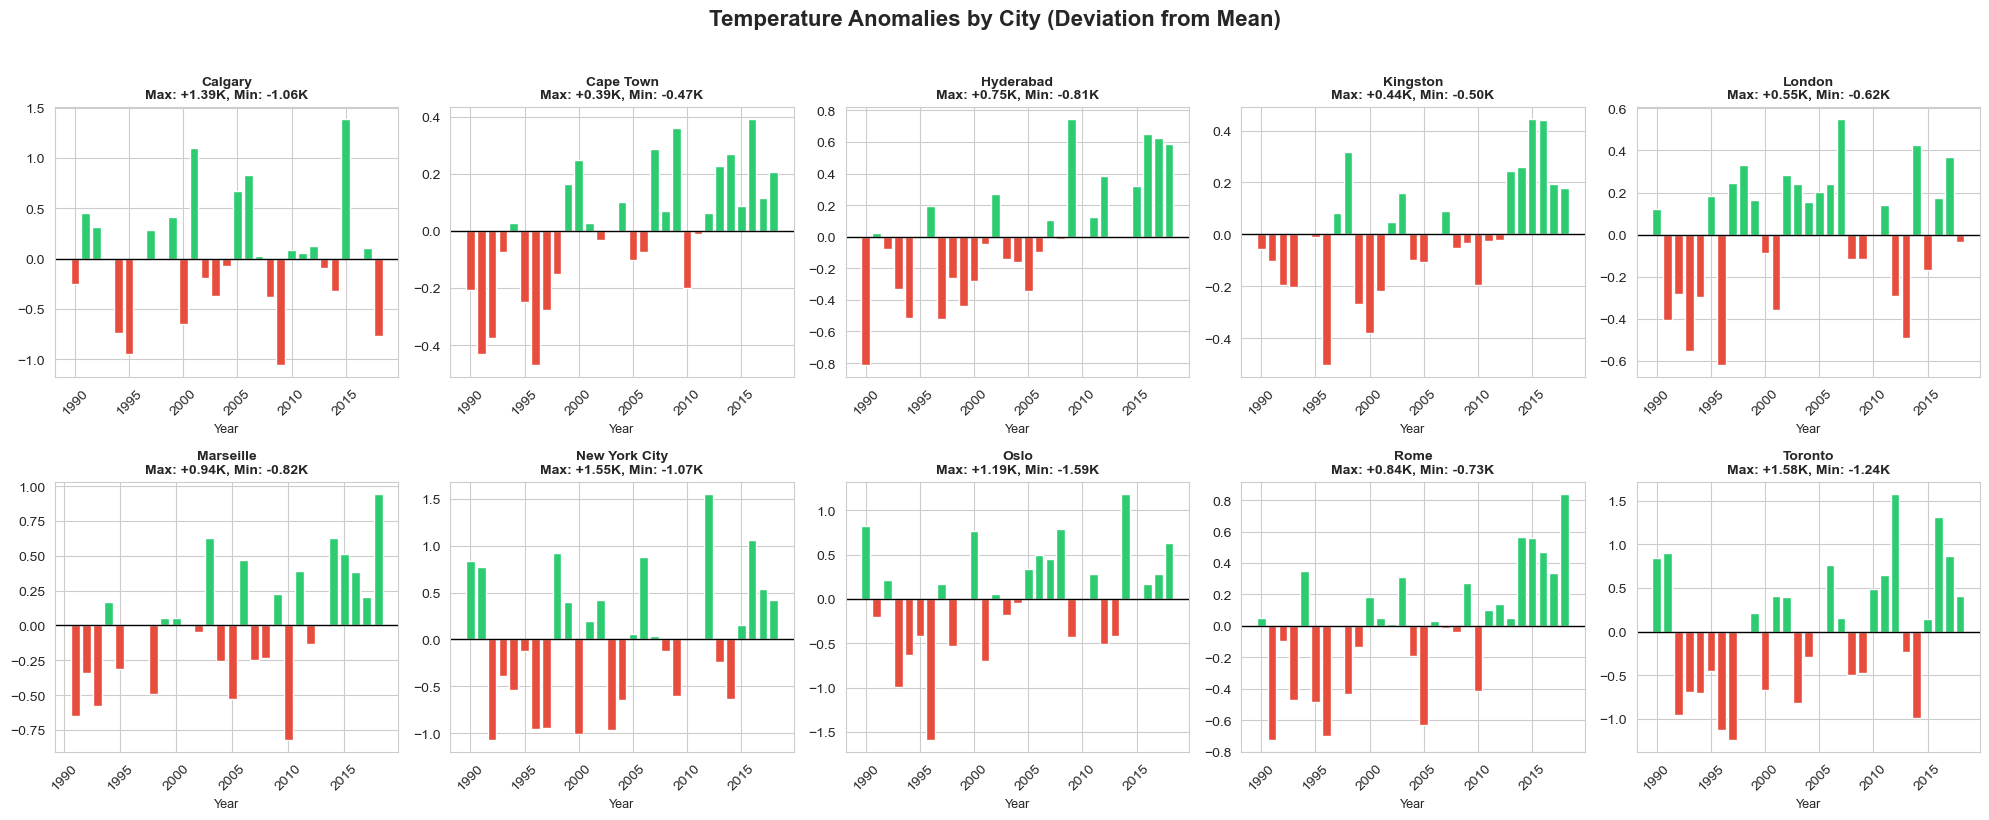


📊 Why important? Shows year-to-year climate variability.


In [22]:
# Climate Anomalies - Deviation from City Average
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

cities = sorted(df['city'].unique())

for i, city in enumerate(cities):
    ax = axes[i]
    city_data = df[df['city'] == city].sort_values('year')
    
    # Calculate anomaly (deviation from mean)
    mean_temp = city_data['temp_mean_K'].mean()
    anomaly = city_data['temp_mean_K'] - mean_temp
    years = city_data['year'].values
    
    # Color bars
    colors = [COLORS['positive'] if x >= 0 else COLORS['negative'] for x in anomaly]
    ax.bar(years, anomaly, color=colors, edgecolor='white', width=0.8)
    ax.axhline(0, color='black', linewidth=1)
    
    # Calculate extremes
    max_anom = anomaly.max()
    min_anom = anomaly.min()
    
    ax.set_title(f'{city}\nMax: +{max_anom:.2f}K, Min: {min_anom:.2f}K', fontsize=10, fontweight='bold')
    ax.set_xlabel('Year', fontsize=9)
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Temperature Anomalies by City (Deviation from Mean)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 Why important? Shows year-to-year climate variability.")


## 10. Key Findings Summary

In [23]:
# Summary Statistics Table
summary_data = []
warming_data = []

for city in sorted(df['city'].unique()):
    city_data = df[df['city'] == city].sort_values('year')
    warming = city_data['temp_mean_K'].iloc[-1] - city_data['temp_mean_K'].iloc[0]
    warming_data.append({'city': city, 'warming': warming})
    summary_data.append({
        'City': city,
        'Country': city_data['country'].iloc[0],
        'Region': city_data['region'].iloc[0],
        'Avg Temp (K)': round(city_data['temp_mean_K'].mean(), 2),
        'Avg Precip (mm)': round(city_data['precip_total_mm'].mean(), 0),
        'Total Warming (K)': round(warming, 2),
        'Avg CO2 (M)': round(city_data['co2_emissions_ton'].mean() / 1e6, 2),
        'HDI (2018)': round(city_data[city_data['year'] == 2018]['hdi'].values[0], 3)
    })

summary_df = pd.DataFrame(summary_data)
warming_df = pd.DataFrame(warming_data)

print("="*100)
print("GLOBAL CITIES CLIMATE & DEVELOPMENT SUMMARY (1990-2018)")
print("="*100)
print(summary_df.to_string(index=False))
print("\n" + "="*100)

# Key insights
print("\n🔍 KEY INSIGHTS:")
print(f"\n1. WARMING TRENDS:")
print(f"   - Average warming across all cities: {warming_df['warming'].mean():.2f} K")
max_warming_city = warming_df.loc[warming_df['warming'].idxmax()]
print(f"   - City with highest warming: {max_warming_city['city']} ({max_warming_city['warming']:.2f} K)")

# Get city temperatures
city_avg_summary = df.groupby('city').agg({
    'temp_mean_K': 'mean',
    'co2_emissions_ton': 'mean',
    'hdi': 'mean'
}).reset_index()

print(f"\n2. TEMPERATURE PATTERNS:")
hyd_temp = city_avg_summary[city_avg_summary['city']=='Hyderabad']['temp_mean_K'].values[0]
kin_temp = city_avg_summary[city_avg_summary['city']=='Kingston']['temp_mean_K'].values[0]
cal_temp = city_avg_summary[city_avg_summary['city']=='Calgary']['temp_mean_K'].values[0]
osl_temp = city_avg_summary[city_avg_summary['city']=='Oslo']['temp_mean_K'].values[0]
print(f"   - Hottest cities: Hyderabad ({hyd_temp:.1f} K), Kingston ({kin_temp:.1f} K)")
print(f"   - Coldest cities: Calgary ({cal_temp:.1f} K), Oslo ({osl_temp:.1f} K)")

print(f"\n3. EMISSIONS:")
nyc_co2 = city_avg_summary[city_avg_summary['city']=='New York City']['co2_emissions_ton'].values[0]/1e6
kin_co2 = city_avg_summary[city_avg_summary['city']=='Kingston']['co2_emissions_ton'].values[0]/1e6
print(f"   - Highest emitter: New York City ({nyc_co2:.1f} M tons/year)")
print(f"   - Lowest emitter: Kingston ({kin_co2:.1f} M tons/year)")

print(f"\n4. DEVELOPMENT:")
osl_hdi = city_avg_summary[city_avg_summary['city']=='Oslo']['hdi'].values[0]
hyd_hdi = city_avg_summary[city_avg_summary['city']=='Hyderabad']['hdi'].values[0]
print(f"   - Highest HDI: Oslo ({osl_hdi:.3f})")
print(f"   - Lowest HDI: Hyderabad ({hyd_hdi:.3f})")
print("\n" + "="*100)


GLOBAL CITIES CLIMATE & DEVELOPMENT SUMMARY (1990-2018)
         City        Country          Region  Avg Temp (K)  Avg Precip (mm)  Total Warming (K)  Avg CO2 (M)  HDI (2018)
      Calgary         Canada   North America        276.03            499.0              -0.52         6.69       0.944
    Cape Town   South Africa          Africa        289.75            564.0               0.41         9.57       0.753
    Hyderabad          India      South Asia        300.62           1049.0               1.40         3.43       0.654
     Kingston        Jamaica       Caribbean        299.94            838.0               0.23         2.57       0.739
       London United Kingdom  Western Europe        283.88           1006.0              -0.16        32.94       0.959
    Marseille         France  Western Europe        289.61            483.0               1.60         2.33       0.891
New York City  United States   North America        281.91           1317.0              -0.42        68

---
## Summary

This notebook analyzed climate and development data across **10 major global cities** from 1990-2018.

**Color Coding Used:**
| City | Color |
|------|-------|
| Cape Town | Coral Red |
| Hyderabad | Teal |
| Kingston | Sky Blue |
| New York City | Sage Green |
| Rome | Cream Yellow |
| Marseille | Plum |
| Toronto | Mint |
| Calgary | Mustard |
| London | Light Purple |
| Oslo | Light Blue |

**Key Takeaways:**
- All cities show warming trends, with significant variation
- Temperature strongly correlated with latitude
- Developed cities have higher emissions but better efficiency
- Cities cluster naturally by geographic region
- Climate variability differs significantly between regions